<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ, 2024</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

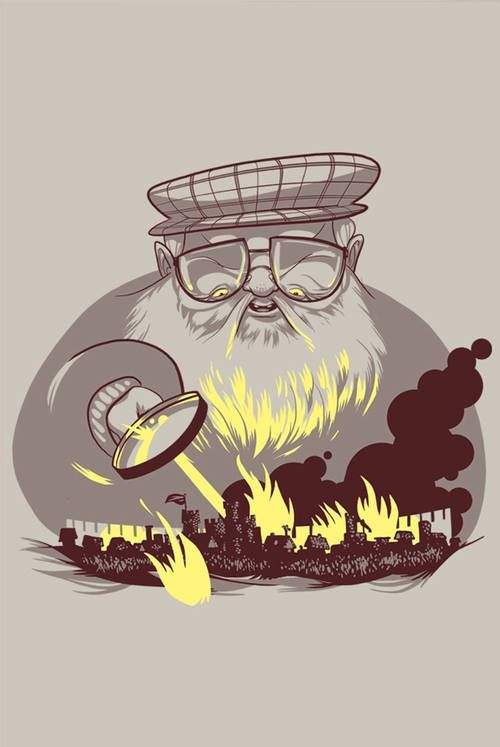

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.84$ --- 5 баллов

2) $0.84 > score \geqslant 0.77$ --- 4 балла

3) $0.77 > score \geqslant 0.70$ --- 3 балла

4) $0.70 > score \geqslant 0.65$ --- 2 балла

5) $0.65 > score \geqslant 0.6$ --- 1 балл

6) $0.60 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [140]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

zsh:1: command not found: gdown
zsh:1: command not found: gdown


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [142]:
data = pd.read_csv("game_of_thrones_train.csv", index_col="S.No")

**Задание 1.3.** Предобработка (очистка) данных.

Проанализируйте, если в колонках NaN значения. Если есть, примите решение, как вы их будете обрабатывать. Вы можете либо удалить их, либо заполнить каким нибудь значением (например, медианой или модой).

In [143]:
data.isna().sum(axis=0)

name                   0
title                840
male                   0
culture             1069
dateOfBirth         1278
mother              1539
father              1535
heir                1536
house                381
spouse              1357
book1                  0
book2                  0
book3                  0
book4                  0
book5                  0
isAliveMother       1539
isAliveFather       1535
isAliveHeir         1536
isAliveSpouse       1357
isMarried              0
isNoble                0
age                 1278
numDeadRelations       0
popularity             0
isAlive                0
dtype: int64

In [144]:
data = data.drop(
    columns=[
        "name",
        "title",
        "culture",
        "dateOfBirth",
        "mother",
        "father",
        "heir",
        "spouse",
        "isAliveMother",
        "isAliveFather",
        "isAliveHeir",
        "isAliveSpouse",
        "age",
    ]
)

In [145]:
data["house"] = data["house"].fillna(data["house"].mode()[0])

**Задание 1.4.** Создайте новые признаки.
* Создайте признак isPopular. У вас есть в таблице признак popularity score, поставьте какой то порог, например, 0.5, и пусть те персонажи, у которых popularity score меньше 0.5, непопулярны, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
* Создайте признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
* Упростите признак culture, объединив схожие названия в один.


In [146]:
# Подсказка
cult = {
    "Summer Islands": ["summer islands", "summer islander", "summer isles"],
    "Ghiscari": ["ghiscari", "ghiscaricari", "ghis"],
    "Asshai": ["asshai'i", "asshai"],
    "Lysene": ["lysene", "lyseni"],
    "Andal": ["andal", "andals"],
    "Braavosi": ["braavosi", "braavos"],
    "Dornish": ["dornishmen", "dorne", "dornish"],
    "Myrish": ["myr", "myrish", "myrmen"],
    "Westermen": ["westermen", "westerman", "westerlands"],
    "Westerosi": ["westeros", "westerosi"],
    "Stormlander": ["stormlands", "stormlander"],
    "Norvoshi": ["norvos", "norvoshi"],
    "Northmen": ["the north", "northmen"],
    "Free Folk": ["wildling", "first men", "free folk"],
    "Qartheen": ["qartheen", "qarth"],
    "Reach": ["the reach", "reach", "reachmen"],
}

In [147]:
"""
В списке cult отображены не все названия, например нет Rivermen, Dornish.
Из 1557 у 1069, так что я удалил этот столбец, но код как бы я сделала, учитывая если cult был бы полностью оформлен я оставил в этой ячейке.

cult_new = {}

for k in cult:
    for item in cult[k]:
        cult_new[item] = k

data["culture"] = data["culture"].apply(lambda x: cult_new.get(x))
"""

'\nВ списке cult отображены не все названия, например нет Rivermen, Dornish. \nИз 1557 у 1069, так что я удалил этот столбец, но код как бы я сделала, учитывая если cult был бы полностью оформлен я оставил в этой ячейке.\n\ncult_new = {}\n\nfor k in cult:\n    for item in cult[k]:\n        cult_new[item] = k\n    \ndata["culture"] = data["culture"].apply(lambda x: cult_new.get(x))\n'

In [148]:
data["isPopular"] = data["popularity"].apply(lambda x: 0 if x <= 0.9 else 1)
data["boolDeadRelations"] = data["numDeadRelations"].apply(lambda x: 0 if x == 0 else 1)

**Задание 1.5.** Проанализируйте, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалите ненужные столбцы по вашему мнению.

In [149]:
repla = []
for house in data["house"].unique():
    if (
        house == "Night's Watch"
        or house == "House Targaryen"
        or house == "House Frey"
        or house == "House Stark"
    ):
        continue
    repla.append(house)

data["house"] = data["house"].fillna("Night's Watch")
data["house"] = data["house"].replace(repla, "Rare")

one_hot = pd.get_dummies(data["house"])
df = pd.concat([data, one_hot], axis=1)
df = df.drop("house", axis=1)
df

,male,book1,book2,book3,book4,book5,isMarried,isNoble,numDeadRelations,popularity,isAlive,isPopular,boolDeadRelations,House Frey,House Stark,House Targaryen,Night's Watch,Rare
S.No,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,11,0.605351,0,0,1,True,False,False,False,False
2,1,1,1,1,1,1,1,1,1,0.896321,1,0,1,True,False,False,False,False
3,1,0,0,0,1,0,0,1,0,0.267559,1,0,0,False,False,False,False,True
4,0,0,0,0,0,0,1,1,0,0.183946,0,0,0,False,False,False,False,True
5,0,0,0,0,1,0,1,1,0,0.043478,1,0,0,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1,1,0,1,1,0,0,1,0,0.160535,1,0,0,True,False,False,False,False
1554,0,1,1,0,0,0,0,0,0,0.040134,0,0,0,True,False,False,False,False
1555,1,0,1,1,1,1,0,0,0,0.076923,0,0,0,False,False,False,False,True


In [150]:
df["House Frey"] = df["House Frey"].apply(lambda x: 0 if x == False else 1)
df["House Stark"] = df["House Stark"].apply(lambda x: 0 if x == False else 1)
df["House Targaryen"] = df["House Targaryen"].apply(lambda x: 0 if x == False else 1)
df["Night's Watch"] = df["Night's Watch"].apply(lambda x: 0 if x == False else 1)
df["Rare"] = df["Rare"].apply(lambda x: 0 if x == False else 1)

# True/False после OHE имею dtype "object", np.corrcoeff не считается

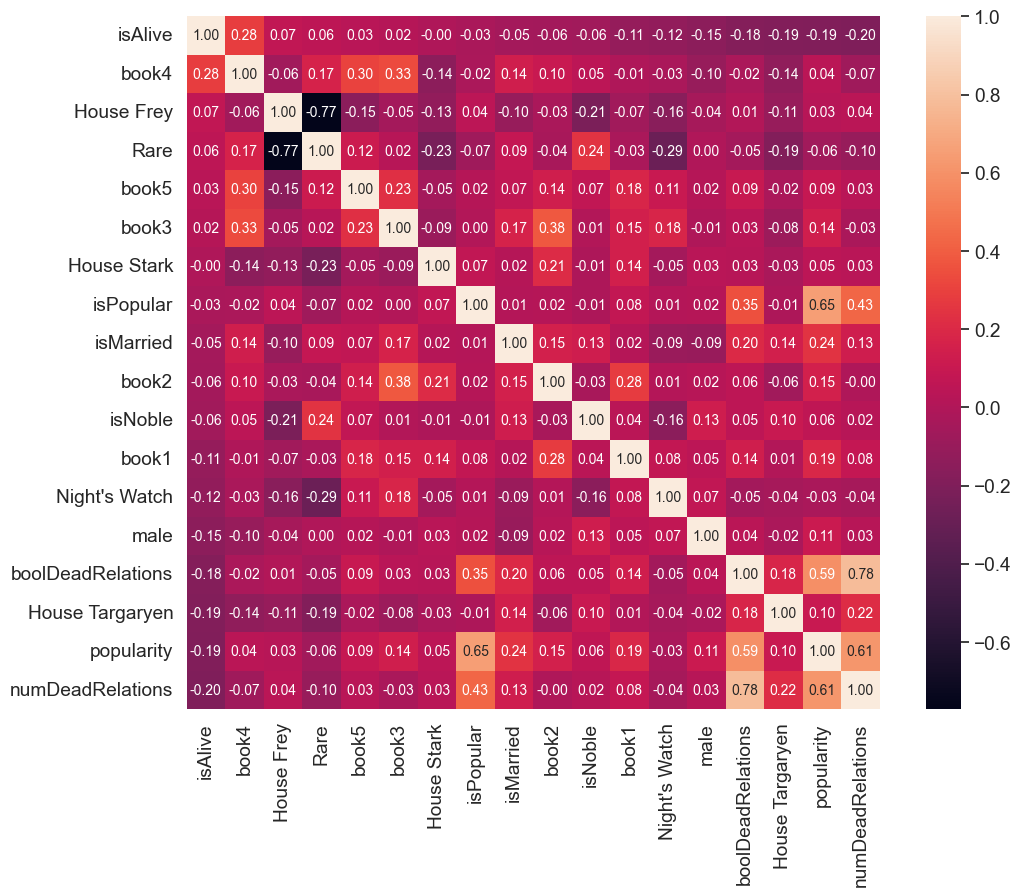

In [151]:
corrmat = df.corr()
f, ax = plt.subplots(figsize=(12, 9))
k = len(df)  # number of variables for heatmap
cols = corrmat.nlargest(k, "isAlive")["isAlive"].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(
    cm,
    cbar=True,
    annot=True,
    square=True,
    fmt=".2f",
    annot_kws={"size": 10},
    yticklabels=cols.values,
    xticklabels=cols.values,
)
plt.show()

In [152]:
df.drop(
    columns=["popularity", "numDeadRelations", "House Targaryen"], inplace=True
)  # "House Targaryen" удалил из-за мультиколлиниарности

(array([ 345.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1212.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

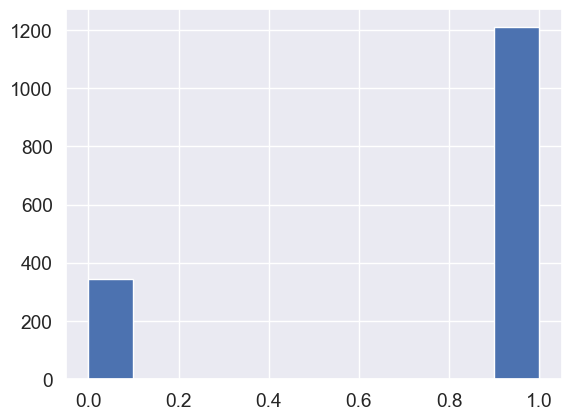

In [153]:
plt.hist(data["isAlive"])

**Задание 1.6.** Проанализируйте целевую переменную. Посмотрите, является ли она категориальной или количественной. Так как мы говорим о задаче классификации, проанализируйте является ли датасет сбалансированным по классам или нет.

(array([345.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 412.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

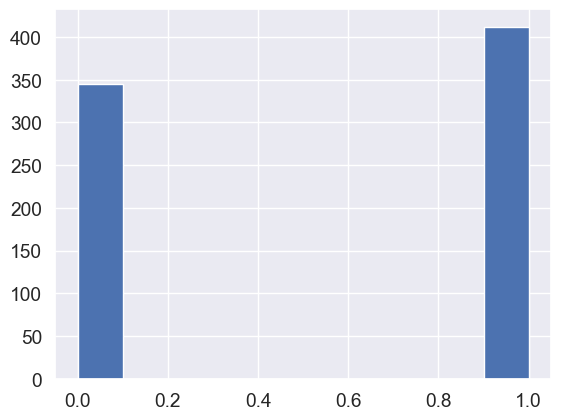

In [154]:
"""
Датасет в дисбалансе, я бы уменьшил выборку или  использовал взвешивание классов
"""

isAlive_rows = df[df["isAlive"] == 1]
rows_to_remove = isAlive_rows.sample(n=800, random_state=42)
df = df.drop(rows_to_remove.index)


plt.hist(df["isAlive"])

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [155]:
# В 1.5 закодировал OHE столбец "house", оставив топ-4 дома + "Rare"
# На каждый соотвествующий столбец своя корелляция

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

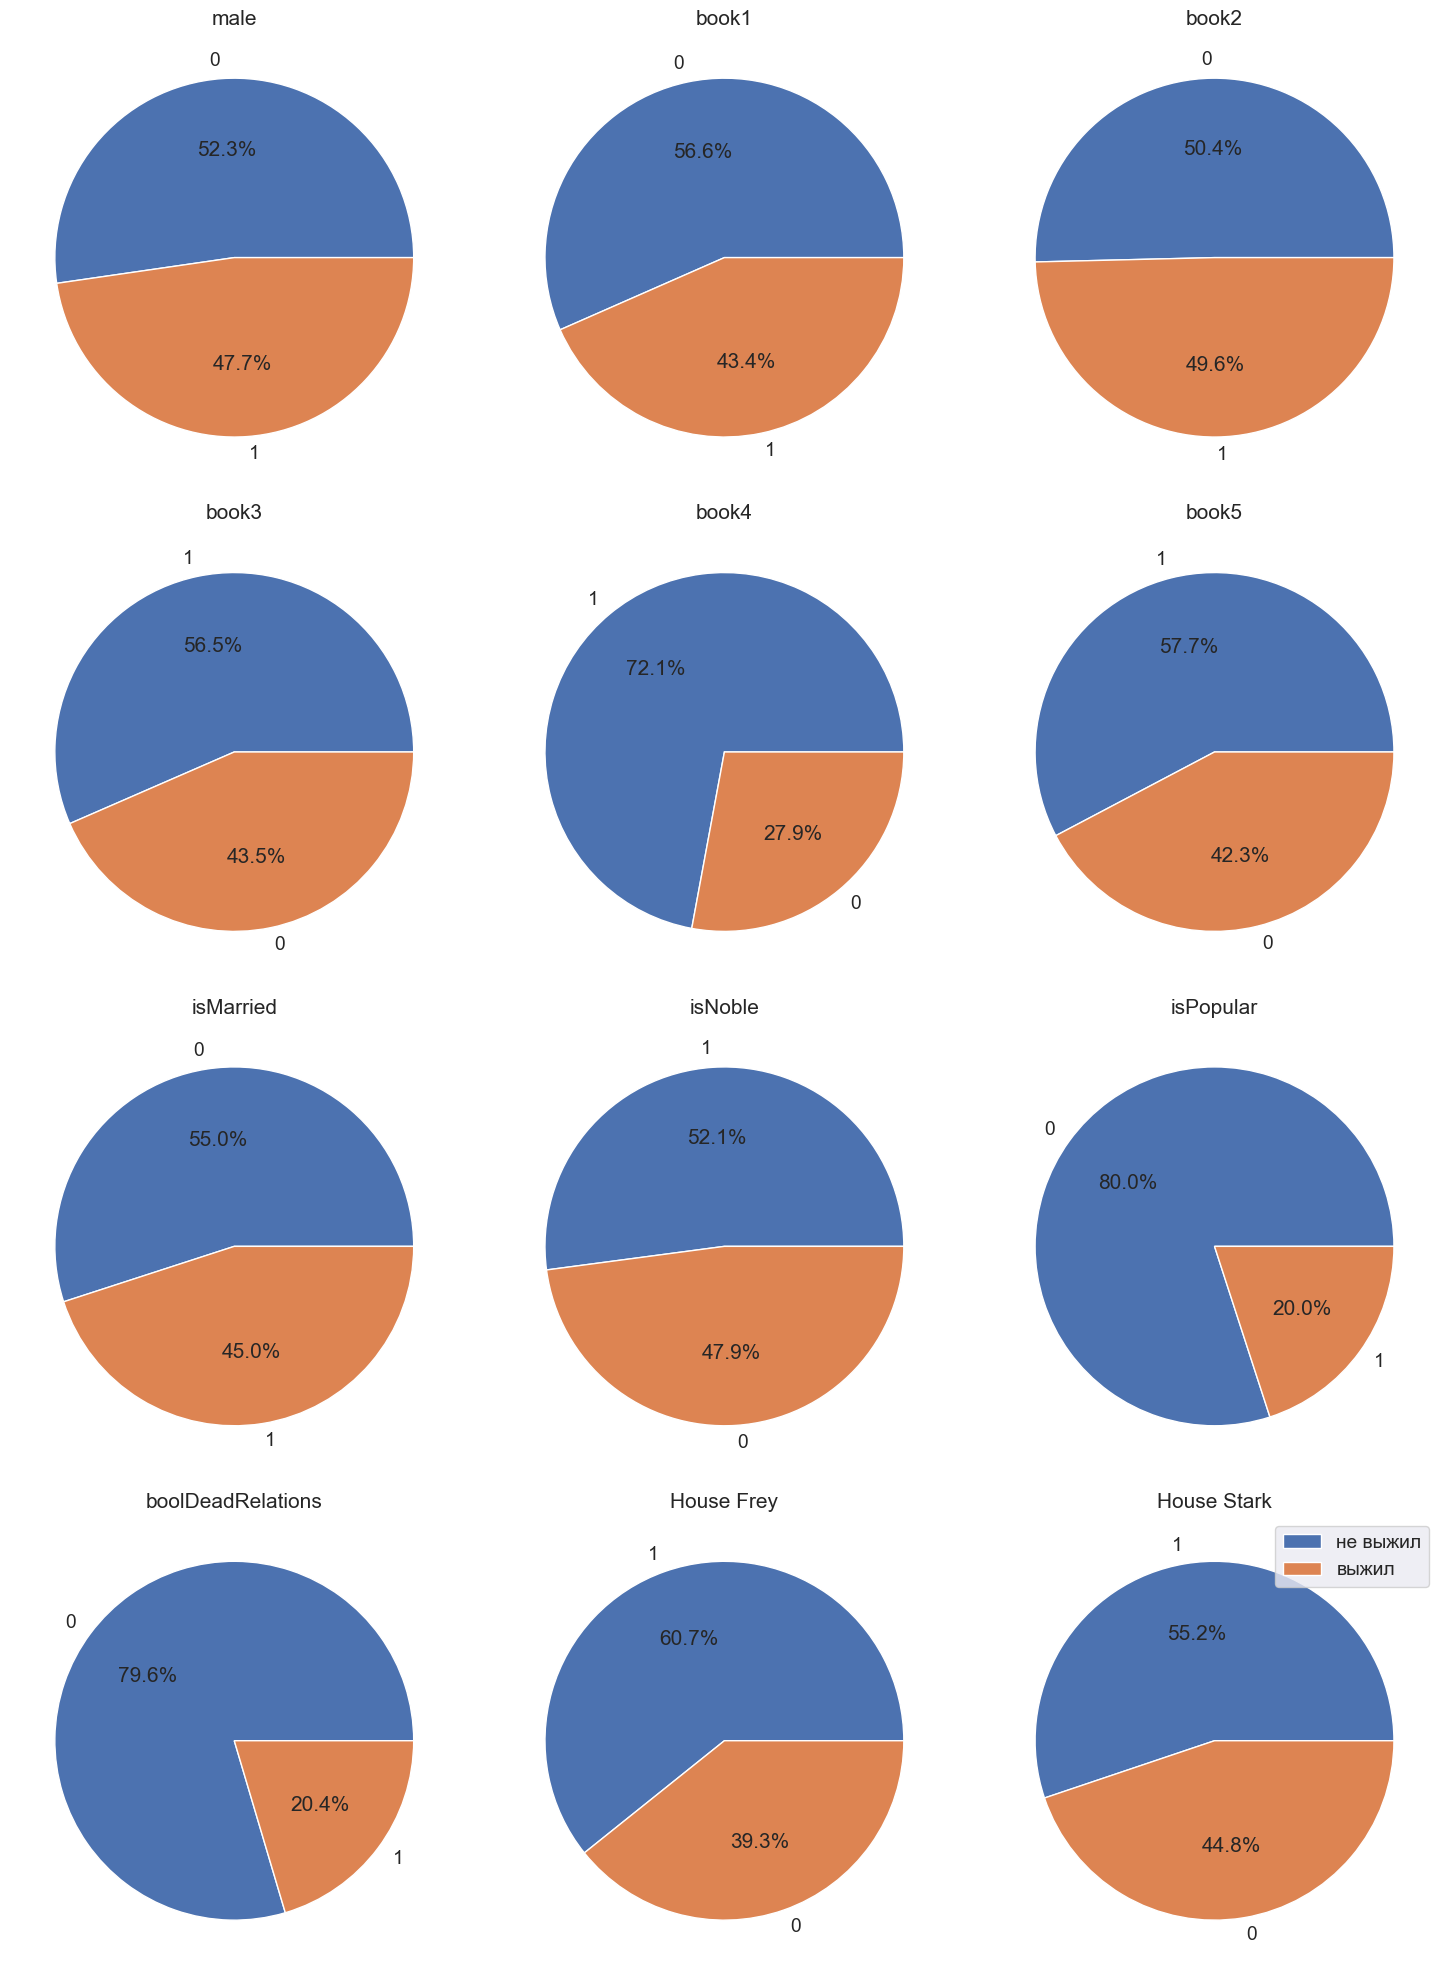

In [156]:
data_list = [
    df[df["male"] == 1]["isAlive"].value_counts(),
    df[df["book1"] == 1]["isAlive"].value_counts(),
    df[df["book2"] == 1]["isAlive"].value_counts(),
    df[df["book3"] == 1]["isAlive"].value_counts(),
    df[df["book4"] == 1]["isAlive"].value_counts(),
    df[df["book5"] == 1]["isAlive"].value_counts(),
    df[df["isMarried"] == 1]["isAlive"].value_counts(),
    df[df["isNoble"] == 1]["isAlive"].value_counts(),
    df[df["isPopular"] == 1]["isAlive"].value_counts(),
    df[df["boolDeadRelations"] == 1]["isAlive"].value_counts(),
    df[df["House Frey"] == 1]["isAlive"].value_counts(),
    df[df["House Stark"] == 1]["isAlive"].value_counts(),
]

titles = [
    "male",
    "book1",
    "book2",
    "book3",
    "book4",
    "book5",
    "isMarried",
    "isNoble",
    "isPopular",
    "boolDeadRelations",
    "House Frey",
    "House Stark",
]

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
axes = axes.flatten()

for i, (data, title) in enumerate(zip(data_list, titles)):
    axes[i].pie(data.values, labels=data.index, autopct="%1.1f%%")
    axes[i].set_title(title)

plt.legend(["не выжил", "выжил"], loc="upper right")

plt.tight_layout()
plt.show()

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

In [157]:
# X = np.array(df.drop(columns = ["isAlive"]))
# y = np.array(df["isAlive"])

**Задание 1.10.** Разделите датасет на train и test часть при помощи функции `train_test_split`

In [158]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=36)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируйте следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

In [159]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

In [160]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [161]:
features = [
    x for x in cols if x not in ["House Targaryen", "popularity", "numDeadRelations"]
]
for i in range(2, len(features) + 2):
    df_local = df[features[:i]]
    X = np.array(df_local.drop(columns=["isAlive"]))
    y = np.array(df_local["isAlive"])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=36
    )

    logistic_regression = LogisticRegression(C=1)
    logistic_regression.fit(X_train, y_train)

    y_pred = logistic_regression.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy : %.4f" % accuracy, f"для топ {i-1} признаков")

Accuracy : 0.6382 для топ 1 признаков
Accuracy : 0.6382 для топ 2 признаков
Accuracy : 0.6382 для топ 3 признаков
Accuracy : 0.6382 для топ 4 признаков
Accuracy : 0.6382 для топ 5 признаков
Accuracy : 0.6711 для топ 6 признаков
Accuracy : 0.6711 для топ 7 признаков
Accuracy : 0.6711 для топ 8 признаков
Accuracy : 0.6513 для топ 9 признаков
Accuracy : 0.6184 для топ 10 признаков
Accuracy : 0.6184 для топ 11 признаков
Accuracy : 0.6250 для топ 12 признаков
Accuracy : 0.6382 для топ 13 признаков
Accuracy : 0.6447 для топ 14 признаков
Accuracy : 0.6447 для топ 15 признаков


**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

In [162]:
models = {
    "AdaBoost": AdaBoostClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GaussianProcess": GaussianProcessClassifier(),
    "NaiveBayes": GaussianNB(),
    "KNeighbors": KNeighborsClassifier(),
    "SVM": SVC(),
    "DecisionTree": DecisionTreeClassifier(),
}

X = np.array(df.drop(columns=["isAlive"]))
y = np.array(df["isAlive"])

for k in range(1, len(features) + 1):
    selector = SelectKBest(f_classif, k=k)
    X_new = selector.fit_transform(X, y)

    X_train, X_test, y_train, y_test = train_test_split(
        X_new, y, test_size=0.2, random_state=36
    )

    print(f"\nКоличество признаков: {k}")
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print(f"{name}: Accuracy = {accuracy:.4f}")


Количество признаков: 1
AdaBoost: Accuracy = 0.6382
RandomForest: Accuracy = 0.6382
GaussianProcess: Accuracy = 0.6382
NaiveBayes: Accuracy = 0.6382
KNeighbors: Accuracy = 0.5395
SVM: Accuracy = 0.6382
DecisionTree: Accuracy = 0.6382

Количество признаков: 2
AdaBoost: Accuracy = 0.6250
RandomForest: Accuracy = 0.6250
GaussianProcess: Accuracy = 0.6250
NaiveBayes: Accuracy = 0.5724
KNeighbors: Accuracy = 0.5724
SVM: Accuracy = 0.6250
DecisionTree: Accuracy = 0.6250

Количество признаков: 3
AdaBoost: Accuracy = 0.5921
RandomForest: Accuracy = 0.6250
GaussianProcess: Accuracy = 0.6250
NaiveBayes: Accuracy = 0.5921
KNeighbors: Accuracy = 0.5724
SVM: Accuracy = 0.6250
DecisionTree: Accuracy = 0.6250

Количество признаков: 4
AdaBoost: Accuracy = 0.6579
RandomForest: Accuracy = 0.6250
GaussianProcess: Accuracy = 0.6250
NaiveBayes: Accuracy = 0.6447
KNeighbors: Accuracy = 0.5789
SVM: Accuracy = 0.6250
DecisionTree: Accuracy = 0.6250

Количество признаков: 5
AdaBoost: Accuracy = 0.6645
RandomF

/Users/pahan/Desktop/part_1_ml_cv/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=15 is greater than n_features=14. All the features will be returned.
  warnings.warn(


In [163]:
k = 2
selector = SelectKBest(f_classif, k=k)
X_new = selector.fit_transform(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=36
)

model = KNeighborsClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"{name}: Accuracy = {accuracy:.4f}")

DecisionTree: Accuracy = 0.5724


In [164]:
scores = selector.scores_
feature_names = df_local.columns[1:]  # Если X — это DataFrame, иначе свой список имен

top_2_indices = np.argsort(scores)[-2:][::-1]
top_2_features = [(feature_names[i], scores[i]) for i in top_2_indices]

In [165]:
top_2_features  # название лучших фия для модели с лучшим скором

[('book3', np.float64(102.56127666896906)),
 ('isNoble', np.float64(25.19045608566556))]

## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

In [166]:
# выполнено выше

Выберите лучшую модель.

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [167]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

zsh:1: command not found: gdown


In [168]:
data_test = pd.read_csv(
    "game_of_thrones_test.csv", index_col="S.No", usecols=["S.No", "book3", "isNoble"]
)

In [169]:
X_test = np.array(data_test)
y_pred = model.predict(X_test)

In [170]:
predictions_df = pd.DataFrame(y_pred, index=data_test.index, columns=["isAlive"])

Как сохранить измененный Pandas DataFrame в csv файл:

In [ ]:
predictions_df.to_csv("submission.csv", index=False)